# EDA and Normal Behaviour

This notebook explores the structure and behaviour of the CATS time series before anomaly-detection models are developed.

The analysis focuses on understanding:

- the normal operating behaviour of the system;
- the behaviour and scale of the 17 signals;
- relationships between signals;
- temporal patterns;
- potential trends, variability, and dependencies;
- differences between the nominal and later evaluation periods.

The first 1,000,000 observations are treated as the nominal period for understanding normal behaviour, based on the official CATS dataset documentation.

No anomaly-detection model will be trained in this notebook.

In [1]:
from pathlib import Path
import pandas as pd

# Project root
PROJECT_ROOT = Path.cwd().parent

# Raw CATS data
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "cats" / "data.parquet"
METADATA_PATH = PROJECT_ROOT / "data" / "raw" / "metadata.csv"

print("Project root:", PROJECT_ROOT)
print("Data file:", DATA_PATH)
print("Metadata file:", METADATA_PATH)

Project root: c:\Users\ADEGOKE\Desktop\CATS
Data file: c:\Users\ADEGOKE\Desktop\CATS\data\raw\cats\data.parquet
Metadata file: c:\Users\ADEGOKE\Desktop\CATS\data\raw\metadata.csv


## Step 1 — Define the Nominal Period

The official CATS documentation identifies the first 1,000,000 observations as nominal.

This period will be used to examine normal system behaviour before analysing the later observations containing anomalous segments.

In [2]:
import pandas as pd

df = pd.read_parquet(DATA_PATH)

nominal_df = df.iloc[:1_000_000].copy()

print("Total observations:", len(df))
print("Nominal observations:", len(nominal_df))
print("Nominal start:", nominal_df.index[0])
print("Nominal end:", nominal_df.index[-1])

Total observations: 5000000
Nominal observations: 1000000
Nominal start: 2023-01-01 00:00:00
Nominal end: 2023-01-12 13:46:39


### Conclusion

The first 1,000,000 observations form the nominal period, covering:

- Start: `2023-01-01 00:00:00`
- End: `2023-01-12 13:46:39`

This period will serve as the reference for understanding normal system behaviour before developing and evaluating anomaly detectors.

## Step 2 — Nominal Signal Statistics

Before examining relationships or temporal patterns, we need to understand the basic numerical behaviour of each signal during the nominal period.

We will examine the minimum, maximum, mean, and standard deviation of the 17 system signals.

These statistics describe the normal scale and variability of each signal.

In [5]:
signal_columns = [
    column
    for column in nominal_df.columns
    if column not in ["y", "category"]
]

print("Number of signal columns:", len(signal_columns))
print(signal_columns)

Number of signal columns: 17
['aimp', 'amud', 'arnd', 'asin1', 'asin2', 'adbr', 'adfl', 'bed1', 'bed2', 'bfo1', 'bfo2', 'bso1', 'bso2', 'bso3', 'ced1', 'cfo1', 'cso1']


In [8]:
signal_summary = nominal_df[
    [
        "aimp", "amud", "arnd", "asin1", "asin2",
        "adbr", "adfl", "bed1", "bed2", "bfo1",
        "bfo2", "bso1", "bso2", "bso3", "ced1",
        "cfo1", "cso1"
    ]
].describe().T[
    ["min", "max", "mean", "std"]
]

print(signal_summary)

             min          max        mean         std
aimp    0.000000     1.000000    0.010102    0.100000
amud  -37.000000    30.000000   -2.864081    9.831507
arnd   10.000000    50.000000   21.574429   10.634474
asin1  -1.000000     1.000000    0.029595    0.699864
asin2  -1.000000     1.000000    0.002564    0.707854
adbr    0.000000     1.000000    0.498540    0.499998
adfl    0.000000     1.000000    0.603450    0.489181
bed1    0.000000     6.068269    1.010185    0.710263
bed2    0.000000     3.468064    0.202040    0.321454
bfo1    0.000000    49.368941   10.929098   11.343483
bfo2    0.000000    78.075280   45.462342   11.997139
bso1  -37.918300    31.074949   -2.861104    9.879527
bso2   -0.745882     1.913420    0.603451    0.684067
bso3    0.000000     0.590806    0.300441    0.098176
ced1    0.000000  1107.280556  383.518693  137.641448
cfo1  -72.237749    32.293983  -10.785074   14.315489
cso1  -20.445898    87.932202   43.200936   15.719292


### Conclusion

The 17 system signals have substantially different numerical scales and levels of variability during the nominal period.

For example, `aimp` ranges from 0 to 1, while `ced1` ranges from 0 to approximately 1,107. Other signals contain both positive and negative values.

This confirms that the signals should not be interpreted using a single absolute threshold or a common numerical scale.

The observed ranges are treated as characteristics of the nominal period at this stage; they are not assumed to represent anomalies.

## Step 3 — Visual Inspection of Nominal Signals

Summary statistics describe the scale and variability of the signals, but they do not show how the signals behave over time.

We will therefore visualize a small selection of signals from the nominal period.

The purpose is to look for:

- stable behaviour;
- oscillations;
- trends;
- changes in variability;
- unusual movements within the nominal period.

This is an exploratory visual check only. No anomaly labels are used to select or interpret the observations.

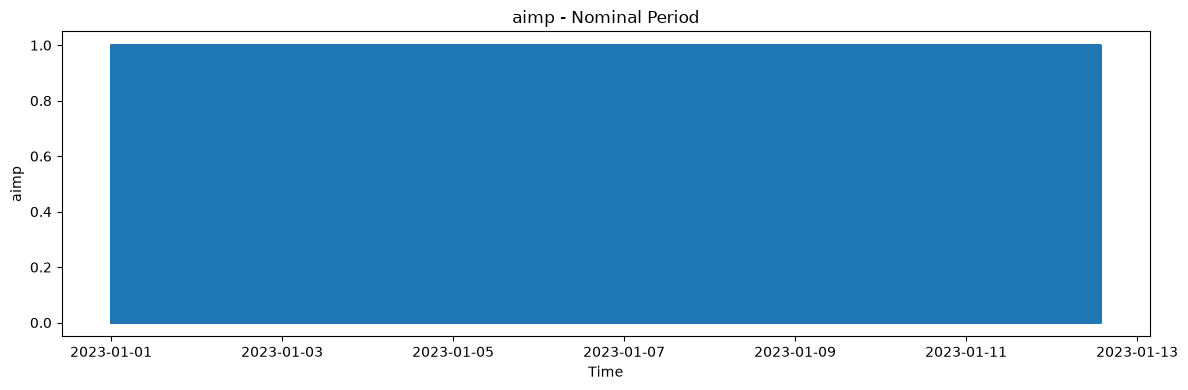

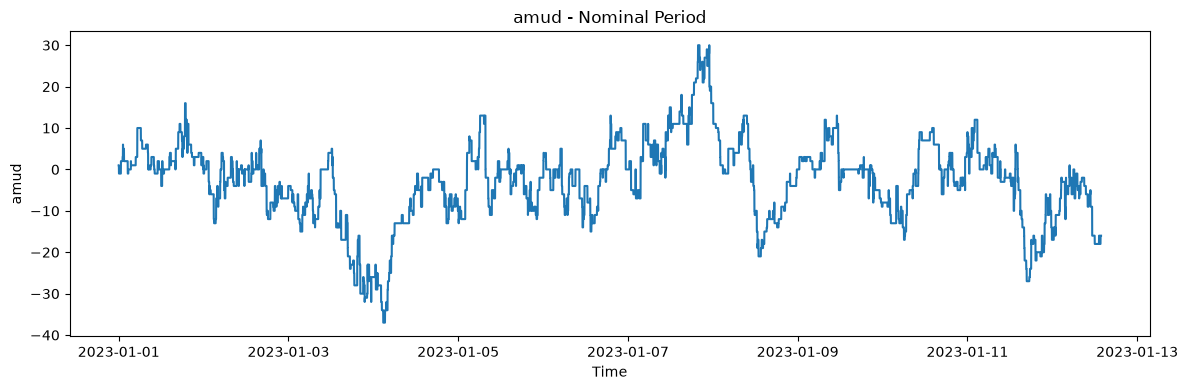

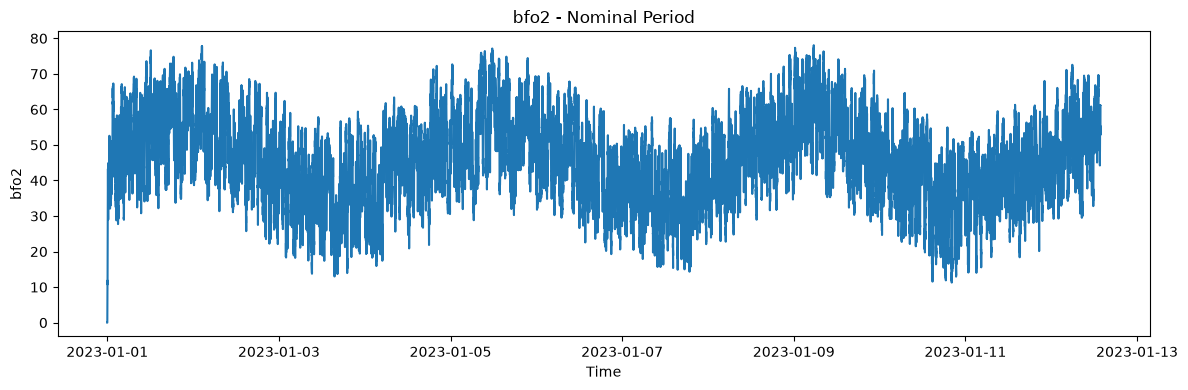

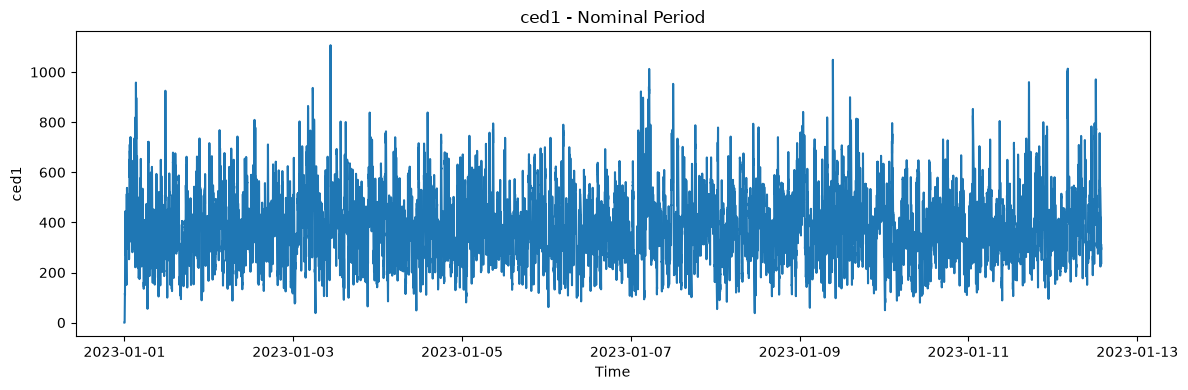

In [10]:
import matplotlib.pyplot as plt

signals_to_plot = ["aimp", "amud", "bfo2", "ced1"]

for signal in signals_to_plot:
    plt.figure(figsize=(12, 4))
    plt.plot(nominal_df.index, nominal_df[signal])
    plt.title(f"{signal} - Nominal Period")
    plt.xlabel("Time")
    plt.ylabel(signal)
    plt.tight_layout()
    plt.show()

### Conclusion

The visual inspection shows that the CATS signals exhibit substantially different normal behaviours.

- `aimp` is bounded between 0 and 1 and has very low average activity during the nominal period. The dense plot is difficult to interpret at the full 1,000,000-observation resolution, so its apparent filled appearance should not be interpreted as a constant value.
- `amud` shows substantial short-term variability around both negative and positive values.
- `bfo2` shows substantial variability across a broad numerical range, with possible slower temporal structure that will require further analysis.
- `ced1` exhibits very high variability and large numerical fluctuations even during the nominal period.

These observations reinforce that anomaly detection cannot rely on a single absolute threshold across all signals. Normal variability differs substantially between channels.

Further temporal analysis will be used to determine whether apparent trends, cycles, or other dependencies are actually present.

## Step 4 — Examine Temporal Behaviour at Lower Resolution

The full nominal period contains 1,000,000 observations, making direct visualization difficult.

To examine broader temporal behaviour, we will temporarily sample one observation every 1,000 seconds.

This does not modify the original data. It is only a visualization technique for identifying broad trends, oscillations, or changes in behaviour over time.

In [12]:
nominal_sample = nominal_df.iloc[::1000]

print("Original nominal observations:", len(nominal_df))
print("Sample observation:", len(nominal_sample))

Original nominal observations: 1000000
Sample observation: 1000


In [ ]:
signals_to_plot = ["aimp", "amud", "bfo2", "ced1"]

for signal in signals_to_plot:
    plt.figure(figsize=(12, 4))
    plt.plot(nominal_sample.index, nominal_sample[signal])
    plt.title()